# Lista 4 - Redes Neurais Artificiais

**Disciplina:** CKP8277 - Aprendizagem Automatica  
**Periodo:** 2026.1  
**Professor:** Cesar Lincoln Cavalcante Mattos  
**Aluno:** Diego Melo do Nascimento  
**Matricula:** 603127

---

**Conteudo:**
- Questao 1: MLP para regressao -- `concrete.csv` (resistencia a compressao do concreto)
- Questao 2: MLP para classificacao -- `vehicle.csv` (silhuetas de veiculos, 4 classes)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')
np.random.seed(42)

## Funcoes Auxiliares

In [2]:
def compute_mean(X):
    return np.sum(X, axis=0) / X.shape[0]

def compute_std(X):
    mu = compute_mean(X)
    return np.sqrt(np.sum((X - mu) ** 2, axis=0) / X.shape[0])

def fit_standardize(X):
    mu    = compute_mean(X)
    sigma = compute_std(X)
    sigma[sigma == 0] = 1
    return mu, sigma

def apply_standardize(X, mu, sigma):
    return (X - mu) / sigma

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)

def softmax(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

def rmse(y, yh):
    return np.sqrt(compute_mean((y - yh) ** 2))

def mae(y, yh):
    return compute_mean(np.abs(y - yh))

def mre(y, yh):
    return compute_mean(np.abs((y - yh) / (y + 1e-8)))

def mse(y, yh):
    return compute_mean((y - yh) ** 2)

def accuracy(y_true, y_pred):
    return compute_mean((y_true == y_pred).astype(float))

def confusion_matrix(y_true, y_pred, classes):
    n = len(classes)
    idx = {c: i for i, c in enumerate(sorted(classes))}
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[idx[int(t)], idx[int(p)]] += 1
    return cm

def precision_recall_f1_macro(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred, classes)
    prec, rec, f1 = [], [], []
    for i in range(len(classes)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        p = tp / (tp + fp + 1e-8)
        r = tp / (tp + fn + 1e-8)
        prec.append(p); rec.append(r)
        f1.append(2 * p * r / (p + r + 1e-8))
    return compute_mean(np.array(prec)), compute_mean(np.array(rec)), compute_mean(np.array(f1))

def cross_entropy_loss(y_oh, probs):
    return -compute_mean(np.sum(y_oh * np.log(probs + 1e-8), axis=1))

def one_hot(y, num_classes):
    Y = np.zeros((len(y), num_classes))
    Y[np.arange(len(y)), y.astype(int)] = 1
    return Y

def train_val_test_split(X, y, train_ratio=0.6, val_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    n_tr = int(len(X) * train_ratio)
    n_va = int(len(X) * val_ratio)
    return (X[idx[:n_tr]], X[idx[n_tr:n_tr+n_va]], X[idx[n_tr+n_va:]],
            y[idx[:n_tr]], y[idx[n_tr:n_tr+n_va]], y[idx[n_tr+n_va:]])

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

def plot_loss_curves(train_l, val_l, title='Curvas de Custo'):
    plt.figure(figsize=(10, 4))
    plt.plot(train_l, color=colors[0], linewidth=2, label='Treino')
    plt.plot(val_l,   color=colors[1], linewidth=2, label='Validacao')
    plt.xlabel('Epoca'); plt.ylabel('Custo'); plt.title(title)
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

def plot_cm(cm, classes, title, ax=None):
    show = ax is None
    if show:
        fig, ax = plt.subplots(figsize=(6, 5))
    cm_pct = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8) * 100
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ax.set_title(title, fontsize=10)
    ticks = list(sorted(classes))
    ax.set_xticks(range(len(ticks))); ax.set_yticks(range(len(ticks)))
    ax.set_xticklabels(ticks); ax.set_yticklabels(ticks)
    ax.set_xlabel('Predito'); ax.set_ylabel('Verdadeiro')
    for i in range(len(ticks)):
        for j in range(len(ticks)):
            color = 'white' if cm_pct[i, j] > 50 else 'black'
            ax.text(j, i, f'{cm_pct[i,j]:.1f}%\n({cm[i,j]})',
                    ha='center', va='center', color=color, fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)
    if show:
        plt.tight_layout(); plt.show()

## Implementacao da MLP

Rede com **1 camada oculta**, treinada com **SGD em mini-batch com momentum**.

**Matrizes de pesos aumentadas** (bias incorporado na coluna 0):

$$W \in \mathbb{R}^{N_H \times (D+1)}, \quad M \in \mathbb{R}^{K \times (N_H+1)}$$

**Forward pass** ($N$ padroes, $\tilde{X} = [1 \; X]$, $\tilde{Z} = [1 \; Z_{1:N_H}]$):

$$U = \tilde{X} W^T, \quad Z_{1:N_H} = \varphi_1(U) = \mathrm{ReLU}(U)$$
$$R = \tilde{Z} M^T, \quad O = \varphi_2(R)$$

**Backward pass:**

$$\delta = -\frac{Y - O}{N}, \quad \zeta = \varphi_1'(U) \odot (\delta \, M_{1:N_H})$$
$$\frac{\partial J}{\partial M} = \delta^T \tilde{Z}, \quad \frac{\partial J}{\partial W} = \zeta^T \tilde{X}$$

**Atualizacao com momentum** ($0{,}5 \le \mu < 1$):

$$\Delta(t+1) = \mu\,\Delta(t) - \alpha\,\frac{\partial J}{\partial w}(t), \quad w(t+1) = w(t) + \Delta(t+1)$$

In [ ]:
class MLP:
    """MLP com 1 camada oculta (matrizes aumentadas W e M)."""

    def __init__(self, n_input, n_hidden, n_output, task='regression',
                 lr=0.01, mu=0.9, batch_size=32, epochs=200, seed=42):
        self.task       = task
        self.lr         = lr
        self.mu         = mu          # momentum 
        self.batch_size = batch_size
        self.epochs     = epochs

        rng = np.random.default_rng(seed)
        # W in R^{N_H x (D+1)},  M in R^{K x (N_H+1)}  — coluna 0 = bias (init 0)
        self.W  = rng.normal(0, np.sqrt(2.0 / n_input),  (n_hidden, n_input  + 1))
        self.W[:, 0] = 0.0
        self.M  = rng.normal(0, np.sqrt(2.0 / n_hidden), (n_output, n_hidden + 1))
        self.M[:, 0] = 0.0
        # velocidades do momentum
        self.vW = np.zeros_like(self.W)
        self.vM = np.zeros_like(self.M)

    @staticmethod
    def _aug(X):
        """Acrescenta coluna de uns em x_0 (entrada aumentada)."""
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def forward(self, X):
        self.X_aug = self._aug(X)                       # (N, D+1)
        self.U     = self.X_aug @ self.W.T              # (N, N_H)
        Z          = relu(self.U)                       # phi_1(U)
        self.Z_aug = self._aug(Z)                       # (N, N_H+1)
        self.R     = self.Z_aug @ self.M.T              # (N, K)
        self.O     = softmax(self.R) if self.task == 'classification' else self.R
        return self.O
    
    def backward(self, Y):
        N          = self.X_aug.shape[0]
        delta      = -(Y - self.O) / N                  # (N, K)
        zeta       = relu_grad(self.U) * (delta @ self.M[:, 1:])  # (N, N_H)
        gM         = delta.T @ self.Z_aug               # (K, N_H+1)
        gW         = zeta.T  @ self.X_aug               # (N_H, D+1)
        return gW, gM

    def update(self, gW, gM):
        clip = 5.0
        np.clip(gW, -clip, clip, out=gW)
        np.clip(gM, -clip, clip, out=gM)
        # Delta(t+1) = mu*Delta(t) - alpha*g;  w(t+1) = w(t) + Delta(t+1)
        self.vW = self.mu * self.vW - self.lr * gW
        self.vM = self.mu * self.vM - self.lr * gM
        self.W += self.vW
        self.M += self.vM

    def fit(self, X_tr, y_tr, X_va, y_va):
        train_l, val_l = [], []
        N = X_tr.shape[0]
        for _ in range(self.epochs):
            idx = np.random.permutation(N)
            Xs, ys = X_tr[idx], y_tr[idx]
            for s in range(0, N, self.batch_size):
                Xb, yb = Xs[s:s+self.batch_size], ys[s:s+self.batch_size]
                self.forward(Xb)
                self.update(*self.backward(yb))
            Ot = self.forward(X_tr)
            Ov = self.forward(X_va)
            if self.task == 'classification':
                train_l.append(cross_entropy_loss(y_tr, Ot))
                val_l.append(cross_entropy_loss(y_va, Ov))
            else:
                train_l.append(mse(y_tr, Ot))
                val_l.append(mse(y_va, Ov))
        return train_l, val_l

    def predict(self, X):
        O = self.forward(X)
        return O.argmax(axis=1) if self.task == 'classification' else O.ravel()

---
## Questao 1 - Regressao: Resistencia a Compressao do Concreto

Dataset: `concrete.csv` - 1029 amostras, 8 atributos, saida continua (MPa)

### Carregamento e Divisao dos Dados

In [4]:
data = np.genfromtxt('data/concrete.csv', delimiter=',', skip_header=1)
X_reg = data[:, :-1]
y_reg = data[:,  -1]

print(f'Amostras: {X_reg.shape[0]} | Features: {X_reg.shape[1]}')
print(f'Saida (MPa): min={y_reg.min():.2f}  max={y_reg.max():.2f}  media={y_reg.mean():.2f}')

X_tr, X_va, X_te, y_tr, y_va, y_te = train_val_test_split(X_reg, y_reg)
print(f'\nTreino: {len(X_tr)} | Validacao: {len(X_va)} | Teste: {len(X_te)}')

mu, sigma = fit_standardize(X_tr)
X_tr_n = apply_standardize(X_tr, mu, sigma)
X_va_n = apply_standardize(X_va, mu, sigma)
X_te_n = apply_standardize(X_te, mu, sigma)

Amostras: 1029 | Features: 8
Saida (MPa): min=2.33  max=82.60  media=35.78

Treino: 617 | Validacao: 205 | Teste: 207


### a) Treinamento da MLP

Hiperparametros ajustados com base no desempenho no conjunto de validacao:

| Hiperparametro | Valor |
|----------------|-------|
| Neuronios ocultos ($N_H$) | 64 |
| Taxa de aprendizado ($\alpha$) | 0.001 |
| Momentum ($\mu$) | 0.9 |
| Mini-batch | 32 |
| Epocas | 300 |

In [5]:
mlp_reg = MLP(
    n_input=X_tr_n.shape[1], n_hidden=64, n_output=1,
    task='regression', lr=0.001, mu=0.9, batch_size=32, epochs=300
)
train_losses_r, val_losses_r = mlp_reg.fit(
    X_tr_n, y_tr.reshape(-1, 1),
    X_va_n, y_va.reshape(-1, 1)
)
print('Treinamento concluido.')

Treinamento concluido.


### b) Curvas de Custo e Metricas

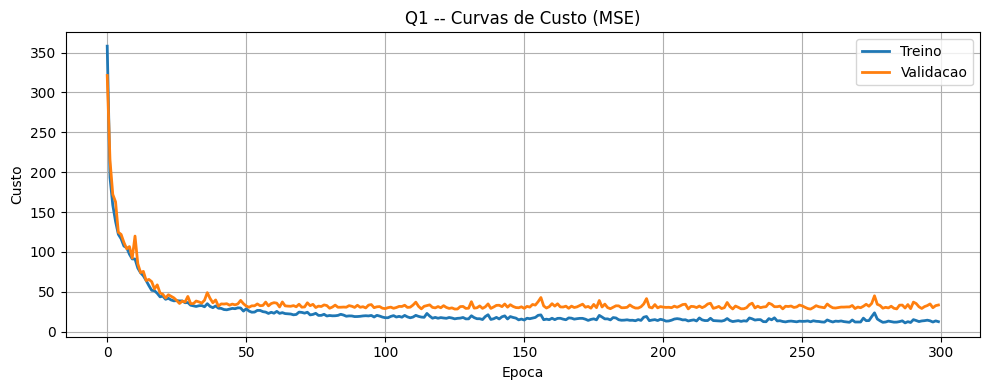

In [6]:
plot_loss_curves(train_losses_r, val_losses_r, title='Q1 -- Curvas de Custo (MSE)')

In [7]:
print('=' * 55)
print(f'{"Conjunto":<12} {"RMSE":>10} {"MAE":>10} {"MRE":>10}')
print('-' * 55)
for name, Xn, yn in [('Treino', X_tr_n, y_tr), ('Validacao', X_va_n, y_va), ('Teste', X_te_n, y_te)]:
    yh = mlp_reg.predict(Xn)
    print(f'{name:<12} {rmse(yn, yh):>10.4f} {mae(yn, yh):>10.4f} {mre(yn, yh):>10.4f}')
print('=' * 55)

Conjunto           RMSE        MAE        MRE
-------------------------------------------------------
Treino           3.5344     2.7343     0.0964
Validacao        5.7801     4.3446     0.1419
Teste            5.7322     4.1232     0.1304


---
## Questao 2 -- Classificacao: Silhuetas de Veiculos

Dataset: `vehicle.csv` - 846 amostras, 18 atributos, 4 classes (bus=0, opel=1, saab=2, van=3)

### Carregamento e Divisao dos Dados

In [8]:
data_v = np.genfromtxt('data/vehicle.csv', delimiter=',')
X_clf  = data_v[:, :-1]
y_clf  = data_v[:,  -1].astype(int)

CLASS_NAMES = ['bus', 'opel', 'saab', 'van']
N_CLASSES   = 4

print(f'Amostras: {X_clf.shape[0]} | Features: {X_clf.shape[1]}')
values, counts = np.unique(y_clf, return_counts=True)
print('Distribuicao de classes:')
for v, c in zip(values, counts):
    print(f'  {CLASS_NAMES[v]:>5}: {c} amostras ({100*c/len(y_clf):.1f}%)')

X_tr2, X_va2, X_te2, y_tr2, y_va2, y_te2 = train_val_test_split(X_clf, y_clf)
print(f'\nTreino: {len(X_tr2)} | Validacao: {len(X_va2)} | Teste: {len(X_te2)}')

mu2, sigma2 = fit_standardize(X_tr2)
X_tr2_n = apply_standardize(X_tr2, mu2, sigma2)
X_va2_n = apply_standardize(X_va2, mu2, sigma2)
X_te2_n = apply_standardize(X_te2, mu2, sigma2)

y_tr2_oh = one_hot(y_tr2, N_CLASSES)
y_va2_oh = one_hot(y_va2, N_CLASSES)

Amostras: 846 | Features: 18
Distribuicao de classes:
    bus: 218 amostras (25.8%)
   opel: 212 amostras (25.1%)
   saab: 217 amostras (25.7%)
    van: 199 amostras (23.5%)



Treino: 507 | Validacao: 169 | Teste: 170


### a) Treinamento da MLP

Hiperparametros ajustados com base no desempenho no conjunto de validacao:

| Hiperparametro | Valor |
|----------------|-------|
| Neuronios ocultos ($N_H$) | 64 |
| Taxa de aprendizado ($\alpha$) | 0.01 |
| Momentum ($\mu$) | 0.9 |
| Mini-batch | 32 |
| Epocas | 300 |

In [9]:
mlp_clf = MLP(
    n_input=X_tr2_n.shape[1], n_hidden=64, n_output=N_CLASSES,
    task='classification', lr=0.01, mu=0.9, batch_size=32, epochs=300
)
train_losses_c, val_losses_c = mlp_clf.fit(
    X_tr2_n, y_tr2_oh,
    X_va2_n, y_va2_oh
)
print('Treinamento concluido.')

Treinamento concluido.


### b) Curvas de Custo, Metricas e Matriz de Confusao

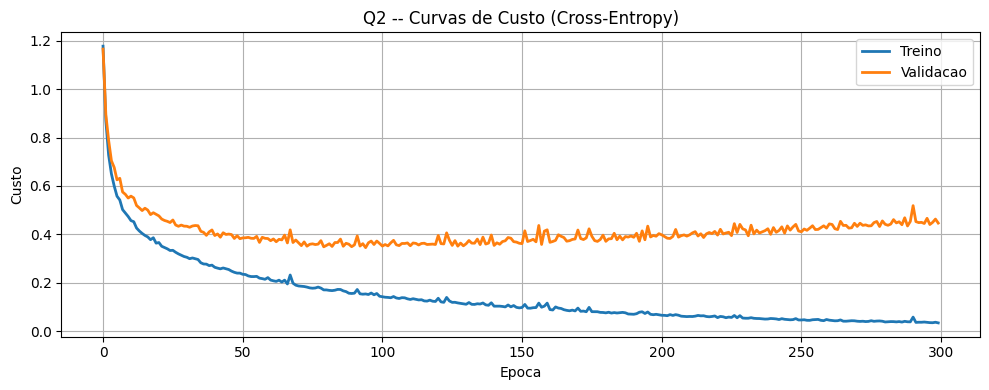

In [10]:
plot_loss_curves(train_losses_c, val_losses_c, title='Q2 -- Curvas de Custo (Cross-Entropy)')

In [11]:
print('=' * 67)
print(f'{"Conjunto":<12} {"Acuracia":>10} {"Precisao":>10} {"Revocacao":>10} {"F1":>10}')
print('-' * 67)
for name, Xn, yn in [('Treino', X_tr2_n, y_tr2), ('Validacao', X_va2_n, y_va2), ('Teste', X_te2_n, y_te2)]:
    yh = mlp_clf.predict(Xn)
    acc = accuracy(yn, yh)
    prec, rec, f1 = precision_recall_f1_macro(yn, yh, list(range(N_CLASSES)))
    print(f'{name:<12} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}')
print('=' * 67)

Conjunto       Acuracia   Precisao  Revocacao         F1
-------------------------------------------------------------------
Treino           1.0000     1.0000     1.0000     1.0000
Validacao        0.8580     0.8665     0.8769     0.8684
Teste            0.7353     0.7391     0.7413     0.7284


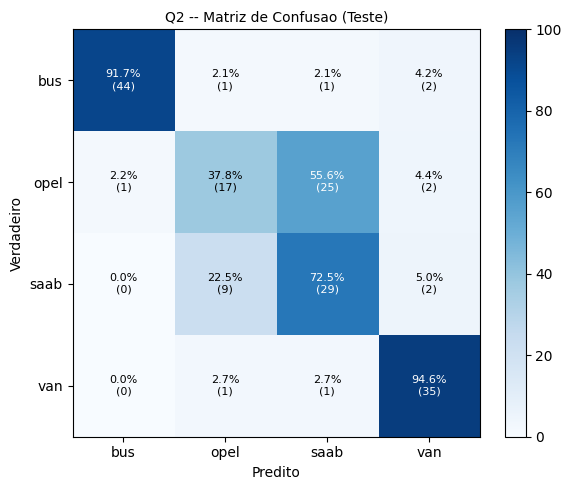

In [12]:
y_hat_te = mlp_clf.predict(X_te2_n)
cm = confusion_matrix(y_te2, y_hat_te, list(range(N_CLASSES)))
plot_cm(cm, CLASS_NAMES, title='Q2 -- Matriz de Confusao (Teste)')